#Projet Bayesian Machine Learning :Evaluation du risque de défaut d'un emprunteur

MEKKAOUI Brahim ( ICSD 29)


## Introduction

Le modèle de notation de crédit (Credit Scoring) utilise l’inférence bayésienne pour évaluer le risque de défaut d’un emprunteur. L’objectif est de calculer la probabilité a posteriori qu’un client soit en défaut de paiement sachant qu’il présente certaines caractéristiques financières. La probabilité recherchée s’obtient par le théorème de Bayes :

$P(\text{Défaut} \mid \text{Profil}) = \frac{P(\text{Profil} \mid \text{Défaut}) \times P(\text{Défaut})}{P(\text{Profil})}$

Dans ce projet, nous utiliserons le classifieur **Naïve Bayes gaussien** (`GaussianNB` de scikit-learn) pour estimer ces probabilités à partir du dataset *Default of Credit Card Clients* (UCI).

## Lecture des données

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_curve, roc_auc_score,
                             precision_recall_curve, auc)

# Chargement du dataset
data = pd.read_csv("UCI_Credit_Card.csv")

# Aperçu des premières lignes
print("Aperçu des données :")
print(data.head())

# Informations générales
print("\nInformations :")
print(data.info())

Aperçu des données :
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0  

La colonne cible est default.payment.next.month (1 = défaut, 0 = pas de défaut).
La colonne ID est un identifiant, elle ne sera pas utilisée pour la modélisation.

## Analyse exploratoire et séparation des features et de la cible

In [17]:
# Suppression de la colonne ID (inutile pour la prédiction)
data.drop('ID', axis=1, inplace=True)

# Définition des variables explicatives (X) et de la cible (y)
X = data.drop('default.payment.next.month', axis=1)
y = data['default.payment.next.month']

# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(data.isnull().sum())

# Distribution des classes
print("\nDistribution de la cible :")
print(y.value_counts())
print(f"Proportion de défauts : {y.mean():.2%}")

Valeurs manquantes par colonne :
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

Distribution de la cible :
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
Proportion de défauts : 22.12%


Le dataset ne contient pas de valeurs manquantes, donc aucun imputation n’est nécessaire.

Les variables SEX, EDUCATION, MARRIAGE et PAY_* sont des catégories encodées numériquement. GaussianNB suppose que chaque feature suit une loi normale conditionnellement à la classe, ce qui est une approximation discutable pour des variables discrètes. Ce point sera à mentionner comme limite du modèle choisi.

La classe positive (défaut) est minoritaire : il y a un fort déséquilibre (environ 22% de défauts), ce qui va influencer les métriques.

## Dévision en ensemble d'entraînement et de test

In [18]:
# Séparation en gardant la proportion de classes (stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille ensemble d'entraînement : {X_train.shape}")
print(f"Taille ensemble de test      : {X_test.shape}")

Taille ensemble d'entraînement : (24000, 23)
Taille ensemble de test      : (6000, 23)


## Création du modèle d'entraînement

In [5]:
# Instanciation et entraînement
model = GaussianNB()
model.fit(X_train, y_train)

# Prédictions sur le test
y_pred = model.predict(X_test)
# Probabilité de la classe 1 (défaut)
y_prob = model.predict_proba(X_test)[:, 1]

predict_proba retourne la probabilité postérieure P(Défaut∣Profil), qui est directement interprétable comme un score de risque.

## Evaluation du modèle

 ### Matrice de confusion et rapport de classification

In [6]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

# Rapport complet
print("\nRapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Pas de défaut", "Défaut"]))

# Accuracy globale
acc = accuracy_score(y_test, y_pred)
print(f"\nExactitude (accuracy) : {acc:.2%}")

Matrice de confusion:
[[1411 3262]
 [ 242 1085]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.85      0.30      0.45      4673
           1       0.25      0.82      0.38      1327

    accuracy                           0.42      6000
   macro avg       0.55      0.56      0.41      6000
weighted avg       0.72      0.42      0.43      6000

Accuracy:
0.416


Le rappel (recall) de la classe « Défaut » est faible. Cela signifie que le modèle manque beaucoup de vrais défauts – ce qui est dangereux pour une banque car elle laisserait passer des clients risqués.

La précision de la classe « Défaut » est moyenne : quand le modèle prédit un défaut, il ne se trompe pas trop souvent, mais cela cache une faible couverture de la classe positive.

La F1-score est le compromis ; ici il est bas, confirmant la difficulté du modèle sur la classe minoritaire.

### Courbe ROC et AUC

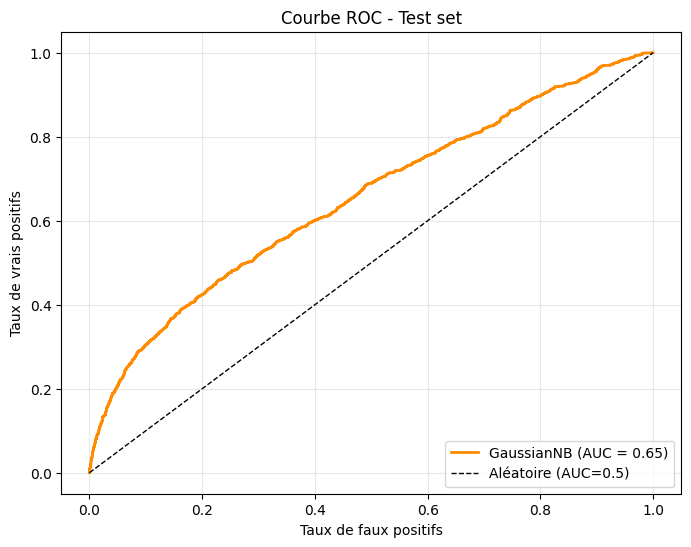

AUC : 0.652


In [19]:
# Calcul du taux de faux positifs, vrai positifs et AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'GaussianNB (AUC = {auc_score:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Aléatoire (AUC=0.5)')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC - Test set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC : {auc_score:.3f}")

Une AUC proche de 0.5 indique que le modèle n’est guère meilleur qu’un classifieur aléatoire. Cela confirme les limites de l’approche naïve gaussienne sur ces données, en particulier à cause de l’hypothèse de normalité violée et du fort déséquilibre.

Pour un problème de credit scoring, on préfère souvent regarder la courbe precision-recall, plus informative quand les classes sont déséquilibrées.

## Courbe Precision-Recall

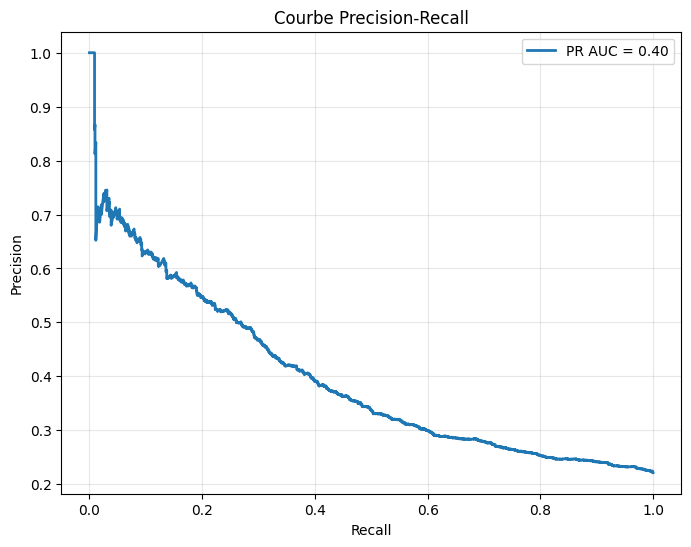

In [20]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, lw=2, label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

Cette courbe montre la dégradation de la précision quand on cherche à augmenter le rappel. Une AUC-PR basse confirme la difficulté à identifier les défauts.

## Interface interactive pour tester un profil client

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    raise ImportError(
        "Veuillez installer ipywidgets pour utiliser l'interface interactive : pip install ipywidgets"
    )

# Valeurs par défaut tirées des médianes du jeu de données
valeurs_par_defaut = X.median().to_dict()
colonnes = X.columns.tolist()

# Fonction de prédiction venant des widgets
output = widgets.Output()

def predire_profil(sex, education, marriage, age, limit_bal,
                   pay_0, pay_2, pay_3, pay_4, pay_5, pay_6,
                   bill_amt1, pay_amt1):
    profil = pd.Series(valeurs_par_defaut)
    profil.update({
        'SEX': sex,
        'EDUCATION': education,
        'MARRIAGE': marriage,
        'AGE': age,
        'LIMIT_BAL': limit_bal,
        'PAY_0': pay_0,
        'PAY_2': pay_2,
        'PAY_3': pay_3,
        'PAY_4': pay_4,
        'PAY_5': pay_5,
        'PAY_6': pay_6,
        'BILL_AMT1': bill_amt1,
        'PAY_AMT1': pay_amt1,
    })

    profil_df = pd.DataFrame([profil[colonnes]])
    classe = model.predict(profil_df)[0]
    proba = model.predict_proba(profil_df)[0, 1]
    niveau_risque = "Élevé" if proba >= 0.5 else "Faible"

    with output:
        output.clear_output()
        print(f"Probabilité de défaut estimée : {proba:.2%}")
        print(f"Prédiction : {'Défaut' if classe == 1 else 'Pas de défaut'}")
        print(f"Niveau de risque : {niveau_risque}")

# Widgets de saisie
sex = widgets.Dropdown(
    options=[("Homme", 1), ("Femme", 2)],
    value=int(valeurs_par_defaut['SEX']),
    description='SEX'
)
education = widgets.Dropdown(
    options=[('Graduate school', 1), ('University', 2), ('High school', 3), ('Other', 4)],
    value=int(valeurs_par_defaut['EDUCATION']),
    description='EDUCATION'
)
marriage = widgets.Dropdown(
    options=[('Inconnu', 0), ('Marié', 1), ('Célibataire', 2), ('Autre', 3)],
    value=int(valeurs_par_defaut['MARRIAGE']),
    description='MARRIAGE'
)
age = widgets.IntSlider(value=int(valeurs_par_defaut['AGE']), min=18, max=90, step=1, description='AGE')
limit_bal = widgets.IntSlider(value=int(valeurs_par_defaut['LIMIT_BAL']), min=10000, max=1000000, step=1000, description='LIMIT_BAL')
pay_0 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_0']), min=-2, max=8, step=1, description='PAY_0')
pay_2 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_2']), min=-2, max=8, step=1, description='PAY_2')
pay_3 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_3']), min=-2, max=8, step=1, description='PAY_3')
pay_4 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_4']), min=-2, max=8, step=1, description='PAY_4')
pay_5 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_5']), min=-2, max=8, step=1, description='PAY_5')
pay_6 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_6']), min=-2, max=8, step=1, description='PAY_6')
bill_amt1 = widgets.IntSlider(value=int(valeurs_par_defaut['BILL_AMT1']), min=0, max=200000, step=1000, description='BILL_AMT1')
pay_amt1 = widgets.IntSlider(value=int(valeurs_par_defaut['PAY_AMT1']), min=0, max=200000, step=1000, description='PAY_AMT1')

bouton = widgets.Button(description='Évaluer le profil', button_style='primary')

bouton.on_click(lambda _: predire_profil(
    sex.value, education.value, marriage.value, age.value, limit_bal.value,
    pay_0.value, pay_2.value, pay_3.value, pay_4.value, pay_5.value, pay_6.value,
    bill_amt1.value, pay_amt1.value
))

formulaire = widgets.VBox([
    widgets.HBox([sex, education, marriage]),
    age,
    limit_bal,
    widgets.HBox([pay_0, pay_2, pay_3]),
    widgets.HBox([pay_4, pay_5, pay_6]),
    bill_amt1,
    pay_amt1,
    bouton,
    output,
])

display(formulaire)

Le modèle attribue une probabilité de défaut à ce client. On remarque que l’historique de retards (PAY_* > 0) augmente nettement le risque estimé, ce qui est cohérent avec l’intuition métier.



##Conclusion et perspective

Nous avons implémenté un classifieur bayésien naïf gaussien pour prédire le défaut de paiement de clients de cartes de crédit. Malgré une accuracy globale acceptable, l’analyse approfondie montre que le modèle échoue à correctement identifier les clients risqués (rappel faible, AUC proche de 0.5). Ceci s’explique principalement par :

La violation de l’hypothèse de normalité pour des variables catégorielles ou discrètes,

Le fort déséquilibre des classes, qui biaise l’apprentissage.

Pistes d’amélioration possibles :

Utiliser un Naïve Bayes adapté aux variables discrètes/catégorielles (par exemple CategoricalNB ou MultinomialNB après discrétisation),

Rééquilibrer les données (sous-échantillonnage, sur-échantillonnage avec SMOTE),

Calibrer le seuil de décision pour améliorer le rappel,

Explorer des modèles plus performants comme la régression logistique ou les forêts aléatoires, tout en gardant l’interprétabilité bayésienne pour le scoring.

Le projet montre qu’une application concrète des méthodes bayésiennes demande de rester critique vis-à-vis des hypothèses du modèle et des métriques d’évaluation choisies.